# PitNextLap — EDA & Classical ML Modeling

## Objective

This notebook recreates the useful modeling choices from the supplied AutoGluon experiment **without using AutoGluon**.

The supplied notebook shows that the strongest search space was built around:
- `PitNextLap` as the target
- ROC-AUC as the evaluation metric
- Gradient boosting families: **LightGBM, XGBoost and CatBoost**
- A LightGBM `extra_trees=True` variant
- `best_quality`-style effort, with **no stacking**

The goal here is to turn those findings into a transparent, human-written workflow: detailed EDA, leakage checks, reproducible validation, 7 classical ML algorithms, focused tuning, model comparison, interpretation and final test prediction.

> The uploaded AutoGluon notebook references `data/train.csv`, `data/train_merged.csv`, `data/test.csv` and `data/sample_submission.csv`, but those CSV files were not included with this upload. This notebook therefore computes all statistics dynamically when those CSVs are placed in the expected `data/` folder. No fake dataset statistics are inserted.

In [1]:
# 1. Imports and reproducibility
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
TARGET = 'PitNextLap'
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
np.random.seed(RANDOM_STATE)
print('Python:', sys.version.split()[0])
print('Random seed:', RANDOM_STATE)
print('Target:', TARGET)

Python: 3.14.2
Random seed: 42
Target: PitNextLap


## Why this step?

A human analyst starts by making the analysis reproducible. The random seed ensures train/validation splits and randomized searches can be repeated. The target is explicitly taken from the supplied notebook rather than inferred.

**Interpretation:** No model result exists yet. This establishes the rules for the later comparison.

In [2]:
# 2. Load the same datasets referenced by the supplied notebook
TRAIN_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\train.csv"
TRAIN_MERGED_PATH =  r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\train_merged.csv"
TEST_PATH =  r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\test.csv"
SAMPLE_PATH =  r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\sample_submission.csv"

for p in [TRAIN_PATH, TRAIN_MERGED_PATH, TEST_PATH, SAMPLE_PATH]:
    print(f'{p}:', 'FOUND' if os.path.exists(p) else 'NOT FOUND')

if not os.path.exists(TRAIN_MERGED_PATH):
    raise FileNotFoundError('data/train_merged.csv was not found. Place the CSV files referenced by the supplied notebook inside a data/ folder.')

df_train_merged = pd.read_csv(TRAIN_MERGED_PATH)
df_train = pd.read_csv(TRAIN_PATH) if os.path.exists(TRAIN_PATH) else None
df_test = pd.read_csv(TEST_PATH) if os.path.exists(TEST_PATH) else None
df_sample_out = pd.read_csv(SAMPLE_PATH) if os.path.exists(SAMPLE_PATH) else None

print('\nLoaded shapes:')
print('train_merged:', df_train_merged.shape)
if df_train is not None: print('train:', df_train.shape)
if df_test is not None: print('test:', df_test.shape)
if df_sample_out is not None: print('sample_submission:', df_sample_out.shape)
display(df_train_merged.head())

D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\train.csv: FOUND
D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\train_merged.csv: FOUND
D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\test.csv: FOUND
D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\sample_submission.csv: FOUND

Loaded shapes:
train_merged: (540445, 15)
train: (439140, 16)
test: (188165, 15)
sample_submission: (188165, 2)


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,SWI,MEDIUM,Mexico City Grand Prix,2023,0,6,1,6.0,12,83.921,-21.244,-10.320,0.084507,0.0,0.0
1,TRU,HARD,Italian Grand Prix,2024,0,24,2,17.0,15,83.845,-22.913,-33.696,0.311688,-9.0,1.0
2,TSU,MEDIUM,Monaco Grand Prix,2023,0,23,1,23.0,9,79.239,0.087,-12.078,0.302632,0.0,0.0
3,PEA,HARD,Italian Grand Prix,2022,1,50,2,33.0,11,87.076,-13.929,-31.804,0.694444,3.0,1.0
4,ANT,HARD,Monaco Grand Prix,2025,0,49,1,49.0,12,78.328,-0.516,-33.315,0.653333,0.0,0.0


## Why use `train_merged`?

The supplied notebook actually trains its main AutoGluon experiment on `df_train_merged`, so the human implementation starts from the same modeling table. This keeps the comparison aligned with the experiment that produced the strong result.

**Interpretation:** Immediately verify row count, feature count, target presence and data types before modeling.

In [3]:
# 3. Basic data audit
assert TARGET in df_train_merged.columns, f'{TARGET} is missing from training data.'
feature_df = df_train_merged.drop(columns=[TARGET]).copy()
print('Shape:', df_train_merged.shape)
print('Duplicate rows:', df_train_merged.duplicated().sum())
print('Duplicate columns:', df_train_merged.columns.duplicated().sum())
print('\nTarget value counts:')
display(df_train_merged[TARGET].value_counts(dropna=False).to_frame('count'))
print('\nTarget proportions:')
display(df_train_merged[TARGET].value_counts(normalize=True, dropna=False).to_frame('proportion'))
print('Missing target:', df_train_merged[TARGET].isna().sum())
if df_train_merged[TARGET].nunique(dropna=True) == 2:
    pos_rate = df_train_merged[TARGET].mean()
    print(f'Positive-class rate: {pos_rate:.4%}')
    print('INTERPRETATION:', 'Strong imbalance: prioritize ROC-AUC/PR-AUC.' if (pos_rate < .10 or pos_rate > .90) else 'No extreme imbalance detected.')

Shape: (540445, 15)
Duplicate rows: 0
Duplicate columns: 0

Target value counts:


,count
PitNextLap,
0.0,427273
1.0,113172



Target proportions:


,proportion
PitNextLap,
0.0,0.790595
1.0,0.209405


Missing target: 0
Positive-class rate: 20.9405%
INTERPRETATION: No extreme imbalance detected.


## Why check the target first?

Class balance changes how metrics should be interpreted. Accuracy can be misleading when one class dominates. The supplied experiment explicitly optimized **ROC-AUC**, so this notebook keeps ROC-AUC as primary and adds PR-AUC as a secondary diagnostic.

In [4]:
# 4. Data types and missing values
summary = pd.DataFrame({
    'dtype': feature_df.dtypes.astype(str),
    'n_unique': feature_df.nunique(dropna=False),
    'missing': feature_df.isna().sum(),
    'missing_pct': feature_df.isna().mean()*100
}).sort_values(['missing_pct','n_unique'], ascending=[False,False])
display(summary.head(100))
num0 = feature_df.select_dtypes(include=np.number).columns.tolist()
cat0 = [c for c in feature_df.columns if c not in num0]
print('Numeric columns:', len(num0))
print('Non-numeric columns:', len(cat0))
print('Columns with missing values:', (summary.missing > 0).sum())
print('INTERPRETATION: Missing values are retained and handled inside pipelines so validation data cannot influence imputation.')

,dtype,n_unique,missing,missing_pct
Cumulative_Degradation,float64,163914,0,0.0
LapTime_Delta,float64,73068,0,0.0
LapTime (s),float64,45108,0,0.0
RaceProgress,float64,1947,0,0.0
Driver,str,887,0,0.0
TyreLife,float64,79,0,0.0
LapNumber,int64,78,0,0.0
Position_Change,float64,37,0,0.0
Race,str,28,0,0.0
Position,int64,20,0,0.0


Numeric columns: 11
Non-numeric columns: 3
Columns with missing values: 0
INTERPRETATION: Missing values are retained and handled inside pipelines so validation data cannot influence imputation.


## Why inspect missingness instead of dropping columns?

Missingness may contain signal. Dropping a feature just because it has nulls can remove predictive information. Imputation is therefore performed inside the model pipeline after the train/validation split.

In [5]:
# 5. Missingness plot
m = summary[summary.missing_pct > 0].head(30)
if len(m):
    plt.figure(figsize=(10, max(4, len(m)*0.25)))
    plt.barh(m.index[::-1], m.missing_pct[::-1])
    plt.xlabel('Missing values (%)'); plt.title('Top Feature Missingness'); plt.tight_layout(); plt.show()
else:
    print('No missing values to visualize.')

No missing values to visualize.


## Human interpretation

Use this plot to distinguish isolated nulls from heavily missing variables. A high missing rate is a reason to investigate the data-generating process, not an automatic reason to delete the feature.

In [6]:
# 6. Identifier, constant and high-cardinality audit
n_rows = len(feature_df)
identifier_candidates, constant_candidates, high_cardinality_candidates = [], [], []
for c in feature_df.columns:
    nu = feature_df[c].nunique(dropna=False); ratio = nu/max(n_rows,1)
    if nu <= 1: constant_candidates.append(c)
    if ratio >= .98: identifier_candidates.append(c)
    if nu >= 50 and ratio >= .50: high_cardinality_candidates.append(c)
print('Constant columns:', constant_candidates)
print('\nPotential identifier / near-unique columns:', identifier_candidates)
print('\nHigh-cardinality candidates:', high_cardinality_candidates[:50])
print('INTERPRETATION: Near-unique fields may be IDs, timestamps or keys. They require leakage review before being removed.')

Constant columns: []

Potential identifier / near-unique columns: []

High-cardinality candidates: []
INTERPRETATION: Near-unique fields may be IDs, timestamps or keys. They require leakage review before being removed.


## Why is leakage review critical?

The aim is valid out-of-sample AUC, not an artificially high score. In a lap/racing problem, future information can easily leak into a feature. A variable should only be used if it would genuinely be available at prediction time.

The notebook does **not** blindly drop every identifier-like variable because a driver, race or lap identifier may legitimately carry structure. Human review is safer.

In [7]:
# 7. Numerical EDA
numeric_cols = feature_df.select_dtypes(include=np.number).columns.tolist()
if numeric_cols:
    num_summary = feature_df[numeric_cols].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
    num_summary['missing_pct'] = feature_df[numeric_cols].isna().mean()*100
    num_summary['n_unique'] = feature_df[numeric_cols].nunique(dropna=False)
    display(num_summary.head(100))
else:
    print('No numeric columns detected.')

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct,n_unique
Year,540445.0,2023.536136,1.039373,2022.000000,2022.000000,2022.000000,2023.000000,2024.000000,2024.000000,2025.000000,2025.000000,2025.000,0.0,4
PitStop,540445.0,0.157781,0.364536,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000,0.0,2
LapNumber,540445.0,24.479035,17.422715,1.000000,1.000000,2.000000,10.000000,21.000000,38.000000,56.000000,67.000000,78.000,0.0,78
Stint,540445.0,1.837094,0.954904,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,4.000000,5.000000,8.000,0.0,8
TyreLife,540445.0,14.230676,9.900217,1.000000,1.000000,2.000000,6.000000,12.000000,20.000000,33.000000,44.000000,78.000,0.0,79
Position,540445.0,9.654416,5.303294,1.000000,1.000000,1.000000,5.000000,10.000000,14.000000,18.000000,20.000000,20.000,0.0,20
LapTime (s),540445.0,91.257805,22.917039,67.012000,70.621000,74.932000,82.433000,90.655000,98.632000,110.644000,129.934680,2526.253,0.0,45108
LapTime_Delta,540445.0,-3.100309,44.235627,-2403.895000,-40.881000,-24.944000,-8.717000,-0.226000,0.338000,21.151000,33.622000,2433.472,0.0,73068
Cumulative_Degradation,540445.0,-26.435289,58.002413,-274.564000,-208.610560,-120.334000,-47.611000,-21.067000,-5.918000,85.891000,122.457000,2412.431,0.0,163914
RaceProgress,540445.0,0.355426,0.256863,0.012821,0.013158,0.028169,0.141026,0.294872,0.541667,0.846154,0.958333,1.000,0.0,1947


## Why inspect distributions?

Extreme values can indicate errors, sentinel values such as `-999`, unit problems, or genuine rare events. Tree models generally do not require scaling, so we do not transform variables just because they are skewed.

,feature,class_0_mean,class_1_mean,absolute_difference
8,Cumulative_Degradation,-21.749264,-44.127049,22.377785
2,LapNumber,22.244474,32.915465,10.670991
4,TyreLife,12.843161,19.469140,6.625979
6,LapTime (s),91.550337,90.153374,1.396963
10,Position_Change,-0.016493,0.452948,0.469441
3,Stint,1.748585,2.171253,0.422668
0,Year,2023.471668,2023.779530,0.307862
7,LapTime_Delta,-3.067288,-3.224977,0.157688
5,Position,9.624556,9.767151,0.142595
9,RaceProgress,0.332510,0.441945,0.109435


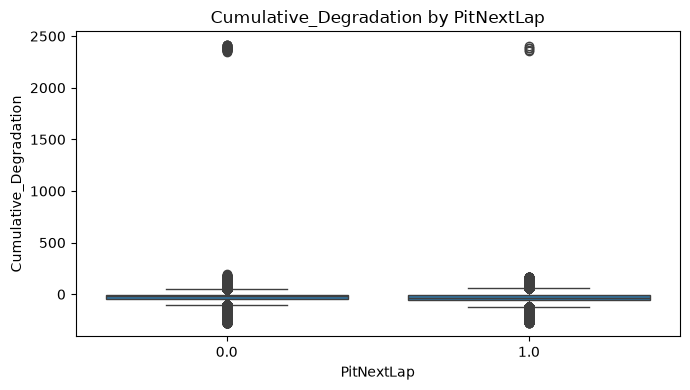

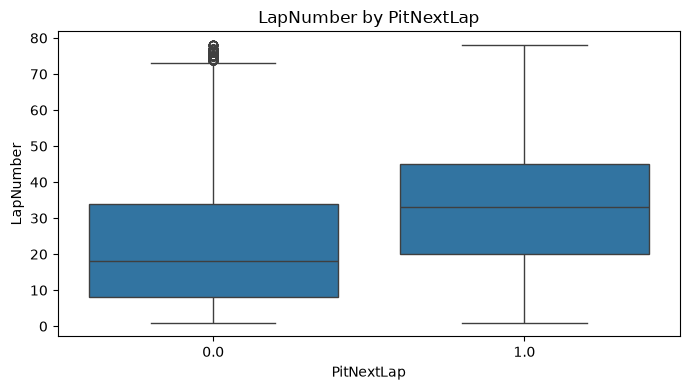

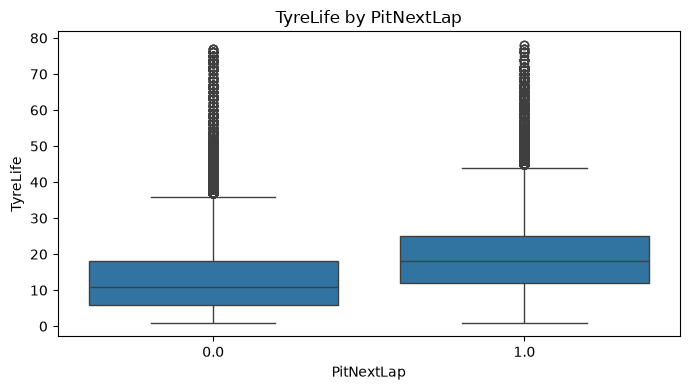

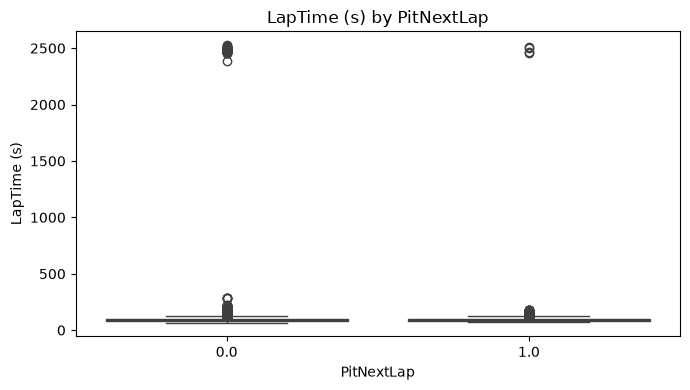

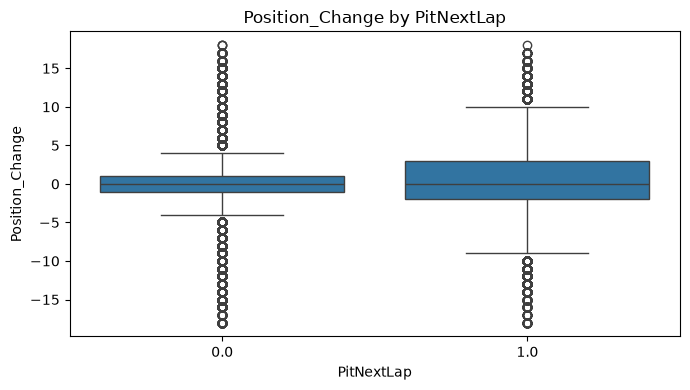

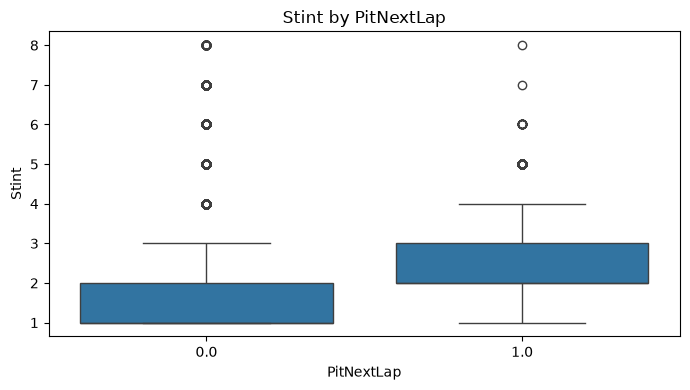

INTERPRETATION: Class-level separation is evidence of possible signal, not proof of causal or leakage-free usefulness.


In [8]:
# 8. Numeric features versus target
if numeric_cols:
    rows=[]
    for c in numeric_cols:
        g=df_train_merged.groupby(TARGET)[c].mean(numeric_only=True)
        if len(g)==2: rows.append({'feature':c,'class_0_mean':g.iloc[0],'class_1_mean':g.iloc[1],'absolute_difference':abs(g.iloc[1]-g.iloc[0])})
    nt=pd.DataFrame(rows).sort_values('absolute_difference', ascending=False)
    display(nt.head(30))
    for c in nt.head(6).feature.tolist():
        plt.figure(figsize=(7,4)); sns.boxplot(data=df_train_merged,x=TARGET,y=c); plt.title(f'{c} by {TARGET}'); plt.tight_layout(); plt.show()
print('INTERPRETATION: Class-level separation is evidence of possible signal, not proof of causal or leakage-free usefulness.')

## Why compare features against the target?

This is a human sanity check. It can reveal variables that appear to explain the target and help us understand model behavior. But univariate separation is not enough: validation performance determines whether the signal generalizes.

,feature_1,feature_2,spearman,abs_spearman
25,LapNumber,RaceProgress,0.980266,0.980266
19,LapNumber,Stint,0.741723,0.741723
32,Stint,RaceProgress,0.737392,0.737392
20,LapNumber,TyreLife,0.655286,0.655286
38,TyreLife,RaceProgress,0.642438,0.642438
45,LapTime (s),LapTime_Delta,0.416618,0.416618
44,Position,Position_Change,-0.278526,0.278526
35,TyreLife,LapTime (s),-0.217458,0.217458
22,LapNumber,LapTime (s),-0.210085,0.210085
46,LapTime (s),Cumulative_Degradation,0.203148,0.203148


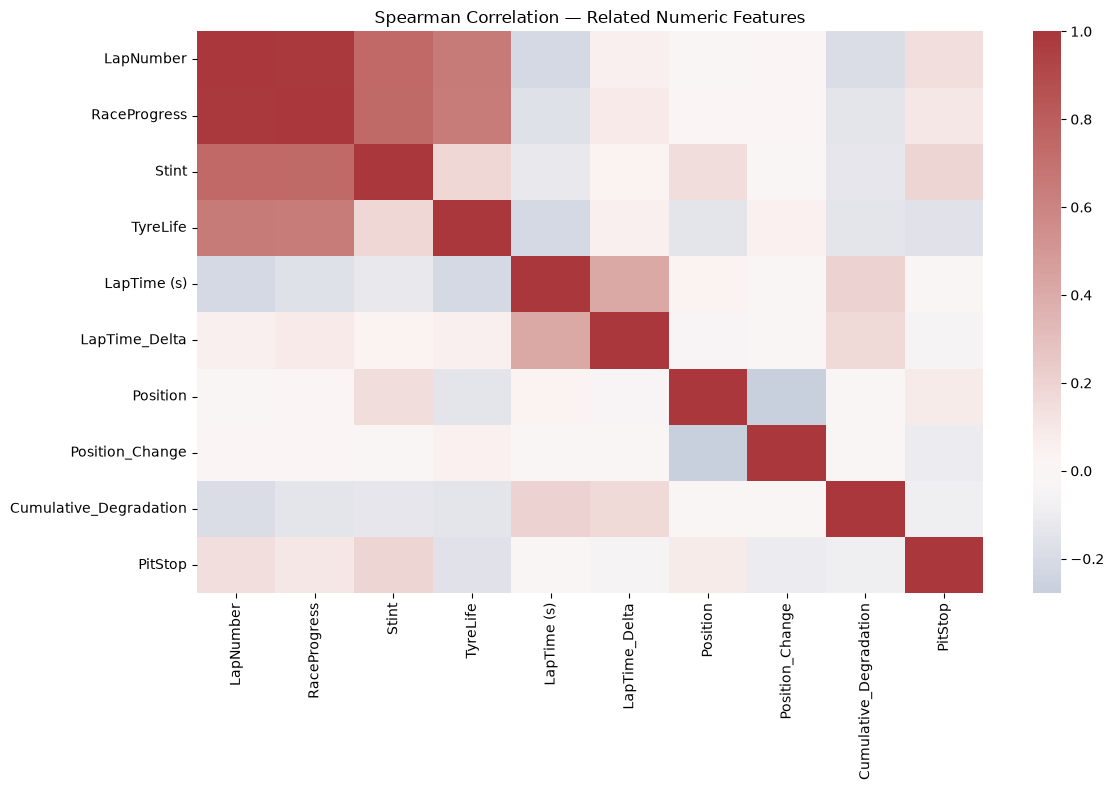

INTERPRETATION: Correlation is reviewed for redundancy and leakage clues, not used as an automatic feature-deletion rule.


In [9]:
# 9. Spearman correlation review
if len(numeric_cols) >= 2:
    corr=feature_df[numeric_cols].corr(method='spearman')
    pairs=[]
    for i,c1 in enumerate(corr.columns):
        for c2 in corr.columns[i+1:]:
            v=corr.loc[c1,c2]
            if pd.notna(v): pairs.append((c1,c2,v,abs(v)))
    cp=pd.DataFrame(pairs,columns=['feature_1','feature_2','spearman','abs_spearman']).sort_values('abs_spearman',ascending=False)
    display(cp.head(30))
    top=list(dict.fromkeys(cp.head(15)[['feature_1','feature_2']].values.ravel()))[:15]
    if len(top)>=2:
        plt.figure(figsize=(12,8)); sns.heatmap(feature_df[top].corr(method='spearman'),cmap='vlag',center=0); plt.title('Spearman Correlation — Related Numeric Features'); plt.tight_layout(); plt.show()
print('INTERPRETATION: Correlation is reviewed for redundancy and leakage clues, not used as an automatic feature-deletion rule.')

## Why Spearman correlation?

Spearman captures monotonic relationships and is less sensitive to extreme values than Pearson. We do not automatically remove correlated variables because tree ensembles can use correlated predictors effectively.

In [10]:
# 10. Categorical EDA
categorical_cols=feature_df.select_dtypes(exclude=np.number).columns.tolist()
cat_rows=[]
for c in categorical_cols:
    vc=feature_df[c].value_counts(dropna=False)
    cat_rows.append({'feature':c,'n_unique':feature_df[c].nunique(dropna=False),'missing_pct':feature_df[c].isna().mean()*100,'top_value':vc.index[0] if len(vc) else None,'top_value_pct':(vc.iloc[0]/len(feature_df)*100) if len(vc) else 0})
cat_summary=pd.DataFrame(cat_rows).sort_values('n_unique',ascending=False)
display(cat_summary.head(100))
for c in categorical_cols[:8]:
    if feature_df[c].nunique(dropna=False)<=20:
        display(Markdown(f'### Target rate by `{c}`'))
        display(pd.crosstab(feature_df[c].fillna('<MISSING>'),df_train_merged[TARGET],normalize='index'))
print('INTERPRETATION: Large target-rate differences across categories indicate possible group-level signal. High-cardinality variables need careful encoding.')

,feature,n_unique,missing_pct,top_value,top_value_pct
0,Driver,887,0.0,NOR,1.295044
2,Race,28,0.0,Dutch Grand Prix,5.541359
1,Compound,5,0.0,MEDIUM,46.032436


### Target rate by `Compound`

PitNextLap,0.0,1.0
Compound,,
HARD,0.673639,0.326361
INTERMEDIATE,0.837431,0.162569
MEDIUM,0.885308,0.114692
SOFT,0.795234,0.204766
WET,0.976625,0.023375


INTERPRETATION: Large target-rate differences across categories indicate possible group-level signal. High-cardinality variables need careful encoding.


## Why inspect categorical variables?

Categorical fields often contain strong group-level signal. For high-cardinality features, one-hot encoding can become very expensive, so the tree pipelines use compact ordinal encoding while Logistic Regression uses one-hot encoding.

In [11]:
# 11. Modeling table and constant-column removal
model_df=df_train_merged.loc[df_train_merged[TARGET].notna()].copy()
X=model_df.drop(columns=[TARGET]); y=model_df[TARGET].astype(int)
constant_cols=[c for c in X.columns if X[c].nunique(dropna=False)<=1]
X=X.drop(columns=constant_cols)
print('Rows used:',len(X)); print('Features used:',X.shape[1]); print('Removed constant columns:',constant_cols)

Rows used: 540445
Features used: 14
Removed constant columns: []


## Why remove constants automatically?

A constant variable contains no information and only adds computational overhead. Identifier-like fields are **not** automatically removed because their meaning must be reviewed for leakage before making that decision.

In [12]:
# 12. Train/validation split
X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=.20,stratify=y,random_state=RANDOM_STATE)
print('Train:',X_train.shape,'| Validation:',X_valid.shape)
print('Train positive rate:',y_train.mean()); print('Validation positive rate:',y_valid.mean())
print('INTERPRETATION: Stratification keeps class proportions similar, making ROC-AUC comparison more stable.')

Train: (432356, 14) | Validation: (108089, 14)
Train positive rate: 0.20940613753480927
Validation positive rate: 0.209401511717196
INTERPRETATION: Stratification keeps class proportions similar, making ROC-AUC comparison more stable.


## Why split before preprocessing?

Imputation, encoding, scaling and feature selection must learn only from training data. Putting preprocessing inside scikit-learn pipelines prevents validation information from leaking into training.

In [13]:
# 13. Preprocessing pipelines
numeric_features=X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features=[c for c in X_train.columns if c not in numeric_features]
linear_preprocessor=ColumnTransformer([('num',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]),numeric_features),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore',min_frequency=2))]),categorical_features)])
tree_preprocessor=ColumnTransformer([('num',Pipeline([('imputer',SimpleImputer(strategy='median'))]),numeric_features),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('ordinal',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))]),categorical_features)])
print('Numeric features:',len(numeric_features)); print('Categorical features:',len(categorical_features))
print('INTERPRETATION: One-hot encoding suits linear models; compact ordinal encoding controls dimensionality for tree ensembles.')

Numeric features: 11
Categorical features: 3
INTERPRETATION: One-hot encoding suits linear models; compact ordinal encoding controls dimensionality for tree ensembles.


# Model strategy

The supplied AutoGluon notebook centered on **GBM, XGB and CAT**, including a LightGBM `extra_trees=True` variant and no stacking. We therefore compare:

1. Logistic Regression
2. Random Forest
3. Extra Trees
4. HistGradientBoosting
5. LightGBM
6. LightGBM Extra Trees
7. XGBoost
8. CatBoost

This gives simple baselines plus the three boosting families that the supplied experiment identified as important.

## Reference benchmark from the supplied AutoGluon notebook

The supplied run provides a useful target for the transparent implementation. Its logged training table contains **540,445 rows**, and the recorded validation ROC-AUCs were approximately:

| AutoGluon model | Validation ROC-AUC |
|---|---:|
| WeightedEnsemble_L2 | **0.959994** |
| XGBoost_BAG_L1 | **0.958240** |
| CatBoost_BAG_L1 | **0.958136** |
| LightGBMLarge_BAG_L1 (`extra_trees=True`) | **0.952897** |
| LightGBM_BAG_L1 | **0.951028** |

The original run used `PitNextLap` with `roc_auc`, `df_train_merged`, `best_quality`, a 9-hour limit and `num_stack_levels=0`. fileciteturn2file1 fileciteturn2file2 fileciteturn3file0

These numbers are **reference benchmarks only**. They are not copied into the new model's evaluation. The new notebook must earn its own AUC on its own validation split.

The practical implication is important: **XGBoost and CatBoost deserve focused tuning first**, while LightGBM and its extra-trees variant remain important comparison points. The original AutoGluon run also used an ensemble, but this notebook deliberately keeps the final solution as a single transparent classical model because the goal is a human-maintained implementation rather than an AutoML ensemble. fileciteturn3file2

In [14]:
# 14. Optional high-performance libraries
available={}
try:
    from lightgbm import LGBMClassifier; available['LightGBM']=True
except Exception as e: available['LightGBM']=False; print('LightGBM unavailable:',e)
try:
    from xgboost import XGBClassifier; available['XGBoost']=True
except Exception as e: available['XGBoost']=False; print('XGBoost unavailable:',e)
try:
    from catboost import CatBoostClassifier; available['CatBoost']=True
except Exception as e: available['CatBoost']=False; print('CatBoost unavailable:',e)
print(available)

{'LightGBM': True, 'XGBoost': True, 'CatBoost': True}


In [15]:
# 15. Define classical models
models={
'Logistic Regression':Pipeline([('prep',linear_preprocessor),('model',LogisticRegression(C=1.0,max_iter=3000,class_weight='balanced',solver='liblinear',random_state=RANDOM_STATE))]),
'Random Forest':Pipeline([('prep',tree_preprocessor),('model',RandomForestClassifier(n_estimators=500,min_samples_leaf=2,max_features='sqrt',class_weight='balanced_subsample',n_jobs=-1,random_state=RANDOM_STATE))]),
'Extra Trees':Pipeline([('prep',tree_preprocessor),('model',ExtraTreesClassifier(n_estimators=500,min_samples_leaf=2,max_features='sqrt',class_weight='balanced',n_jobs=-1,random_state=RANDOM_STATE))]),
'HistGradientBoosting':Pipeline([('prep',tree_preprocessor),('model',HistGradientBoostingClassifier(learning_rate=.05,max_iter=300,max_leaf_nodes=31,min_samples_leaf=20,l2_regularization=1.0,random_state=RANDOM_STATE))])}
if available['LightGBM']:
    models['LightGBM']=Pipeline([('prep',tree_preprocessor),('model',LGBMClassifier(objective='binary',n_estimators=600,learning_rate=.03,num_leaves=31,min_child_samples=20,subsample=.85,colsample_bytree=.85,reg_alpha=.1,reg_lambda=1.0,extra_trees=False,n_jobs=-1,random_state=RANDOM_STATE,verbosity=-1))])
    models['LightGBM Extra Trees']=Pipeline([('prep',tree_preprocessor),('model',LGBMClassifier(objective='binary',n_estimators=600,learning_rate=.03,num_leaves=31,min_child_samples=20,subsample=.85,colsample_bytree=.85,reg_alpha=.1,reg_lambda=1.0,extra_trees=True,n_jobs=-1,random_state=RANDOM_STATE,verbosity=-1))])
if available['XGBoost']:
    models['XGBoost']=Pipeline([('prep',tree_preprocessor),('model',XGBClassifier(objective='binary:logistic',eval_metric='auc',n_estimators=700,learning_rate=.03,max_depth=6,min_child_weight=2,subsample=.85,colsample_bytree=.85,reg_alpha=.1,reg_lambda=1.0,tree_method='hist',n_jobs=-1,random_state=RANDOM_STATE))])
if available['CatBoost']:
    models['CatBoost']=Pipeline([('prep',tree_preprocessor),('model',CatBoostClassifier(iterations=700,learning_rate=.03,depth=7,l2_leaf_reg=5.0,loss_function='Logloss',eval_metric='AUC',verbose=False,random_seed=RANDOM_STATE,thread_count=-1))])
print('Models:',list(models))

Models: ['Logistic Regression', 'Random Forest', 'Extra Trees', 'HistGradientBoosting', 'LightGBM', 'LightGBM Extra Trees', 'XGBoost', 'CatBoost']


## Why these starting values?

They are evidence-based translations of the supplied AutoGluon configuration: boosting models, small learning rates, hundreds of trees/iterations, moderate complexity, sampling and regularization. They are strong starting points rather than a claim of global optimality.

In [16]:
# 16. Baseline cross-validated comparison
cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=RANDOM_STATE)
scoring = {'roc_auc':'roc_auc','average_precision':'average_precision','accuracy':'accuracy'}
baseline_results = []
for name,model in models.items():
    print('Training:',name); start=time.time()
    scores=cross_validate(model,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1,return_train_score=False)
    baseline_results.append({'Model':name,'CV ROC-AUC Mean':scores['test_roc_auc'].mean(),'CV ROC-AUC Std':scores['test_roc_auc'].std(),'CV PR-AUC Mean':scores['test_average_precision'].mean(),'CV Accuracy Mean':scores['test_accuracy'].mean(),'Time (sec)':time.time()-start})
baseline_results_df=pd.DataFrame(baseline_results).sort_values('CV ROC-AUC Mean',ascending=False).reset_index(drop=True)
display(baseline_results_df) 
print('INTERPRETATION: Mean CV ROC-AUC is primary; standard deviation shows stability across folds.')

Training: Logistic Regression
Training: Random Forest
Training: Extra Trees
Training: HistGradientBoosting
Training: LightGBM
Training: LightGBM Extra Trees
Training: XGBoost
Training: CatBoost


,Model,CV ROC-AUC Mean,CV ROC-AUC Std,CV PR-AUC Mean,CV Accuracy Mean,Time (sec)
0,Random Forest,0.952747,0.000273,0.840491,0.902580,351.252712
1,Extra Trees,0.949389,0.000502,0.833448,0.888106,258.667196
2,XGBoost,0.946701,0.000352,0.817870,0.894661,81.230536
3,LightGBM,0.945061,0.000372,0.812458,0.892908,34.254472
4,HistGradientBoosting,0.943677,0.000484,0.807690,0.891233,46.702869
5,CatBoost,0.941300,0.000519,0.802168,0.890030,127.767686
6,LightGBM Extra Trees,0.933363,0.000876,0.781234,0.882442,57.664207
7,Logistic Regression,0.843385,0.000296,0.569291,0.760239,40.103411


INTERPRETATION: Mean CV ROC-AUC is primary; standard deviation shows stability across folds.


## Why cross-validation?

A single split can accidentally favor one model. Three-fold stratified CV provides a more stable estimate while keeping the notebook practical. The supplied experiment used ROC-AUC, so that remains the primary ranking metric.

In [17]:
# 17. Fixed validation-set comparison
validation_results=[]; fitted_models={}
for name,model in models.items():
    print('Fitting:',name); start=time.time(); model.fit(X_train,y_train); elapsed=time.time()-start
    p=model.predict_proba(X_valid)[:,1]; pred=(p>=.5).astype(int)
    validation_results.append({'Model':name,'Validation ROC-AUC':roc_auc_score(y_valid,p),'Validation PR-AUC':average_precision_score(y_valid,p),'Accuracy':accuracy_score(y_valid,pred),'Precision':precision_score(y_valid,pred,zero_division=0),'Recall':recall_score(y_valid,pred,zero_division=0),'F1':f1_score(y_valid,pred,zero_division=0),'Fit Time (sec)':elapsed})
    fitted_models[name]=model 
validation_results_df=pd.DataFrame(validation_results).sort_values('Validation ROC-AUC',ascending=False).reset_index(drop=True)
display(validation_results_df) 
print('Best baseline:',validation_results_df.iloc[0]['Model'],'AUC:',round(validation_results_df.iloc[0]['Validation ROC-AUC'],5))

Fitting: Logistic Regression
Fitting: Random Forest
Fitting: Extra Trees
Fitting: HistGradientBoosting
Fitting: LightGBM
Fitting: LightGBM Extra Trees
Fitting: XGBoost
Fitting: CatBoost


,Model,Validation ROC-AUC,Validation PR-AUC,Accuracy,Precision,Recall,F1,Fit Time (sec)
0,Random Forest,0.954398,0.846810,0.905337,0.761425,0.797959,0.779264,286.127697
1,Extra Trees,0.950873,0.838314,0.890035,0.692354,0.854599,0.764969,2482.821905
2,XGBoost,0.945832,0.815765,0.894023,0.755684,0.729875,0.742555,24.314437
3,LightGBM,0.944500,0.811067,0.892413,0.753934,0.721790,0.737512,17.057584
4,HistGradientBoosting,0.942654,0.805751,0.890590,0.750116,0.716047,0.732685,20.585530
5,CatBoost,0.940466,0.799968,0.888647,0.744848,0.712203,0.728160,53.141576
6,LightGBM Extra Trees,0.932232,0.779169,0.881958,0.735242,0.681806,0.707517,16.152166
7,Logistic Regression,0.842736,0.573239,0.760762,0.458321,0.783423,0.578315,22.194849


Best baseline: Random Forest AUC: 0.9544


## Why show both CV and fixed-validation results?

CV measures stability across several folds. The held-out validation set gives a clean, easy-to-understand comparison after fitting. If both rankings broadly agree, confidence increases. If they disagree sharply, investigate instead of blindly chasing the highest score.

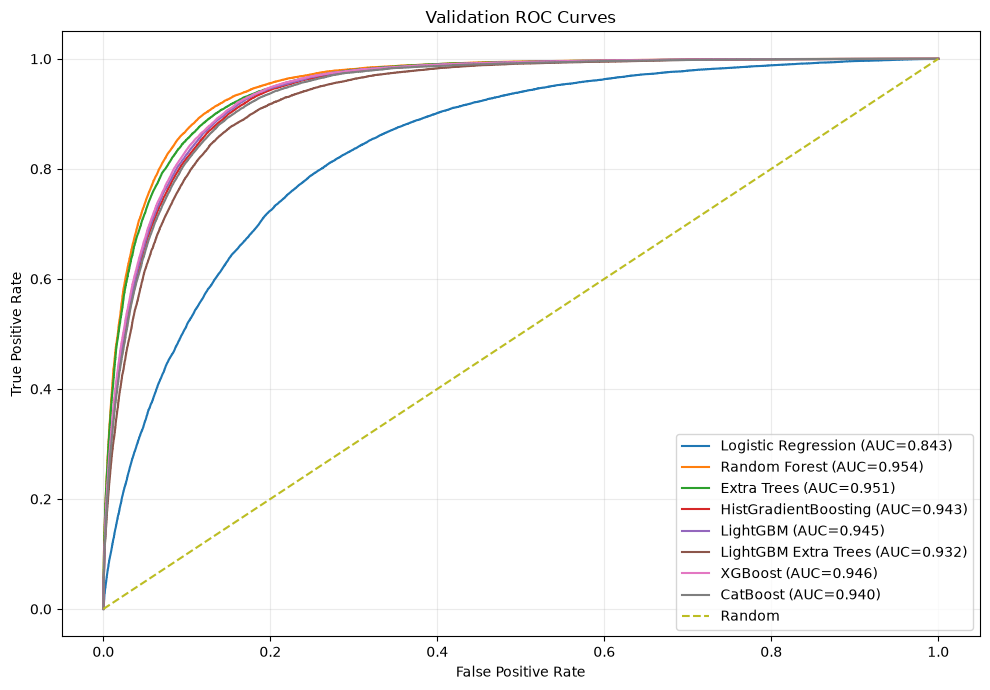

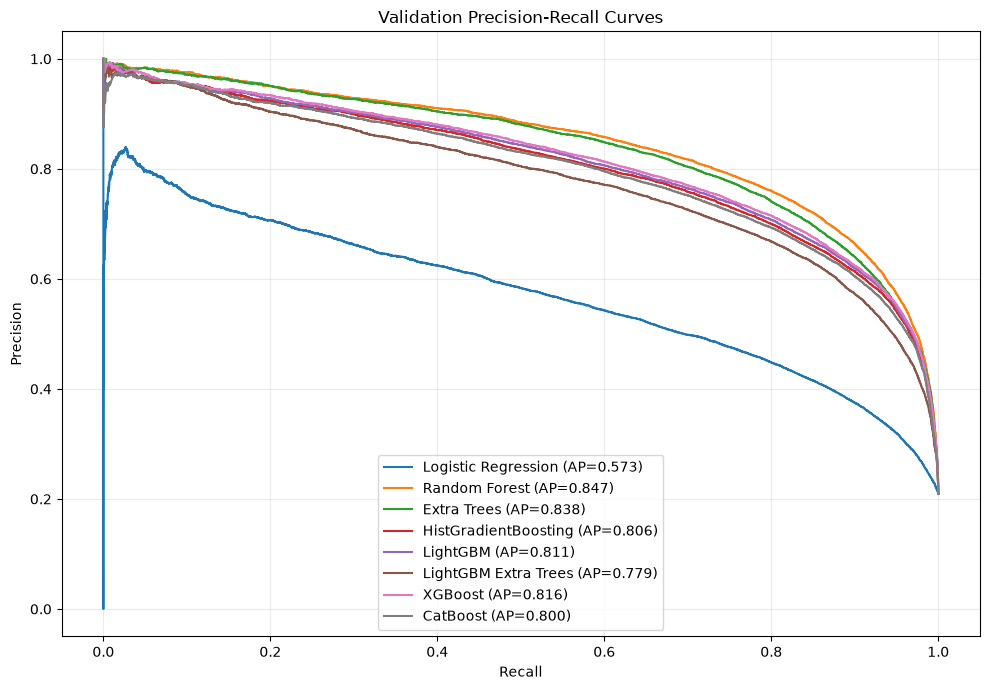

In [18]:
# 18. ROC and PR curves
plt.figure(figsize=(10,7))
for name,model in fitted_models.items():
    p=model.predict_proba(X_valid)[:,1]; fpr,tpr,_=roc_curve(y_valid,p); auc=roc_auc_score(y_valid,p); plt.plot(fpr,tpr,label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'--',label='Random'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('Validation ROC Curves'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,7))
for name,model in fitted_models.items():
    p=model.predict_proba(X_valid)[:,1]; precision,recall,_=precision_recall_curve(y_valid,p); ap=average_precision_score(y_valid,p); plt.plot(recall,precision,label=f'{name} (AP={ap:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Validation Precision-Recall Curves'); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

## Interpretation of the curves

ROC-AUC evaluates ranking over all thresholds. PR-AUC focuses more directly on positive-class quality and is particularly useful when positives are uncommon.

A strong ROC-AUC model should also produce sensible concentration of positives in its high-score region. This is checked later using score buckets.

# Focused tuning

The supplied experiment specifically highlighted LightGBM, XGBoost and CatBoost. We therefore spend compute on these families rather than hiding a massive automated search across every algorithm.

In [19]:
# 19. Hyperparameter spaces
candidates=[n for n in ['LightGBM','LightGBM Extra Trees','XGBoost','CatBoost'] if n in models]
param_distributions={}
for n in ['LightGBM','LightGBM Extra Trees']:
    if n in candidates:
        param_distributions[n]={'model__n_estimators':[400,600,800,1000],'model__learning_rate':[.015,.03,.05,.08],'model__num_leaves':[15,31,63,127],'model__min_child_samples':[10,20,40,80],'model__subsample':[.75,.85,1.0],'model__colsample_bytree':[.70,.85,1.0],'model__reg_alpha':[0,.1,.5,1.0],'model__reg_lambda':[.5,1,2,5]}
if 'XGBoost' in candidates:
    param_distributions['XGBoost']={'model__n_estimators':[400,600,800,1000],'model__learning_rate':[.015,.03,.05,.08],'model__max_depth':[3,4,5,6,7,8],'model__min_child_weight':[1,2,5,10],'model__subsample':[.70,.85,1.0],'model__colsample_bytree':[.70,.85,1.0],'model__reg_alpha':[0,.1,.5,1.0],'model__reg_lambda':[.5,1,2,5]}
if 'CatBoost' in candidates:
    param_distributions['CatBoost']={'model__iterations':[400,600,800,1000],'model__learning_rate':[.015,.03,.05,.08],'model__depth':[4,5,6,7,8,9],'model__l2_leaf_reg':[1,3,5,8,12],'model__random_strength':[0,.5,1,2]}
print('Tuning candidates:',candidates)

Tuning candidates: ['LightGBM', 'LightGBM Extra Trees', 'XGBoost', 'CatBoost']


## Why these tuning parameters?

`learning_rate` and tree count control how gradually the model learns; leaves/depth control complexity; minimum child size limits overfitting; sampling improves generalization; L1/L2 regularization controls complexity.

The ranges are intentionally practical. We are using the AutoGluon result as evidence about where to spend compute, while keeping every choice visible and human-auditable.

In [20]:
# 20. Randomized tuning
# Increase n_iter if more compute/time is available. 20 is a practical starting point for a same-day run.
tuned_results=[]; tuned_models={}
for name in candidates:
    print('\nTuning',name)
    search=RandomizedSearchCV(models[name],param_distributions[name],n_iter=20,scoring='roc_auc',cv=cv,random_state=RANDOM_STATE,n_jobs=1,verbose=1,refit=True)
    start=time.time(); search.fit(X_train,y_train); elapsed=time.time()-start
    tuned_models[name]=search.best_estimator_ 
    tuned_results.append({'Model':name,'Best CV ROC-AUC':search.best_score_,'Tuning Time (sec)':elapsed,'Best Parameters':search.best_params_})
tuned_results_df=pd.DataFrame(tuned_results).sort_values('Best CV ROC-AUC',ascending=False).reset_index(drop=True)
display(tuned_results_df[['Model','Best CV ROC-AUC','Tuning Time (sec)']])    


Tuning LightGBM
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Tuning LightGBM Extra Trees
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Tuning XGBoost
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Tuning CatBoost
Fitting 3 folds for each of 20 candidates, totalling 60 fits


,Model,Best CV ROC-AUC,Tuning Time (sec)
0,LightGBM,0.956306,788.564966
1,XGBoost,0.956014,978.245298
2,CatBoost,0.949674,3631.672992
3,LightGBM Extra Trees,0.949631,1104.505332


## Why randomized search instead of a huge grid?

Every grid combination is multiplied by the number of CV folds. Randomized search explores a broader parameter space for a fixed budget. This is especially effective for boosted trees where only a subset of parameters usually matters strongly.

In [21]:
# 21. Evaluate tuned models on untouched validation data
tuned_validation=[]
for name,model in tuned_models.items():
    p=model.predict_proba(X_valid)[:,1]; pred=(p>=.5).astype(int)
    tuned_validation.append({'Model':name,'Validation ROC-AUC':roc_auc_score(y_valid,p),'Validation PR-AUC':average_precision_score(y_valid,p),'Accuracy':accuracy_score(y_valid,pred),'Precision':precision_score(y_valid,pred,zero_division=0),'Recall':recall_score(y_valid,pred,zero_division=0),'F1':f1_score(y_valid,pred,zero_division=0)})
tuned_validation_df=pd.DataFrame(tuned_validation).sort_values('Validation ROC-AUC',ascending=False).reset_index(drop=True)
display(tuned_validation_df)

,Model,Validation ROC-AUC,Validation PR-AUC,Accuracy,Precision,Recall,F1
0,XGBoost,0.956784,0.851667,0.909778,0.794056,0.768446,0.781041
1,LightGBM,0.956760,0.850823,0.909741,0.793402,0.769285,0.781157
2,LightGBM Extra Trees,0.949587,0.830334,0.900656,0.776831,0.737430,0.756618
3,CatBoost,0.949128,0.826617,0.899046,0.769174,0.739949,0.754279


## Why evaluate on a separate validation set?

The CV folds are used to choose hyperparameters. The untouched validation set then tells us whether the selected configuration actually improves out-of-sample performance. This prevents reporting the best search score as though it were final generalization.

,Model,Validation ROC-AUC,Validation PR-AUC,Accuracy,Precision,Recall,F1,Stage
0,XGBoost,0.956784,0.851667,0.909778,0.794056,0.768446,0.781041,Tuned
1,LightGBM,0.956760,0.850823,0.909741,0.793402,0.769285,0.781157,Tuned
2,Random Forest,0.954398,0.846810,0.905337,0.761425,0.797959,0.779264,Baseline
3,Extra Trees,0.950873,0.838314,0.890035,0.692354,0.854599,0.764969,Baseline
4,LightGBM Extra Trees,0.949587,0.830334,0.900656,0.776831,0.737430,0.756618,Tuned
5,CatBoost,0.949128,0.826617,0.899046,0.769174,0.739949,0.754279,Tuned
6,XGBoost,0.945832,0.815765,0.894023,0.755684,0.729875,0.742555,Baseline
7,LightGBM,0.944500,0.811067,0.892413,0.753934,0.721790,0.737512,Baseline
8,HistGradientBoosting,0.942654,0.805751,0.890590,0.750116,0.716047,0.732685,Baseline
9,CatBoost,0.940466,0.799968,0.888647,0.744848,0.712203,0.728160,Baseline


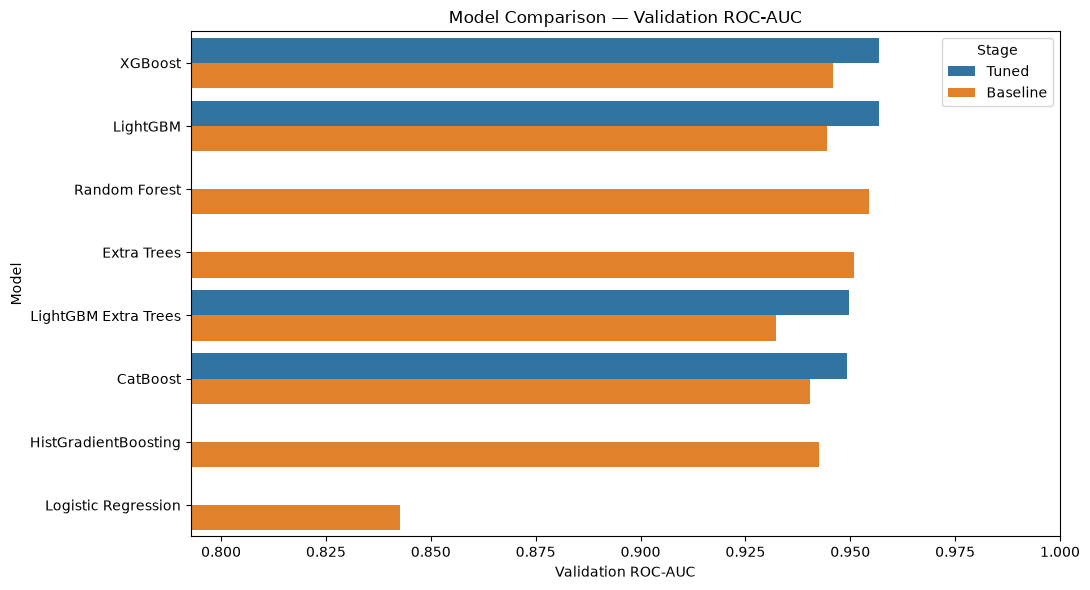

Selected model: XGBoost
Validation ROC-AUC: 0.95678


In [22]:
# 22. Final comparison and selection
comparison=validation_results_df[['Model','Validation ROC-AUC','Validation PR-AUC','Accuracy','Precision','Recall','F1']].copy(); comparison['Stage']='Baseline'
if len(tuned_validation_df):
    tc=tuned_validation_df.copy(); tc['Stage']='Tuned'; comparison=pd.concat([comparison,tc[comparison.columns]],ignore_index=True)
comparison=comparison.sort_values(['Validation ROC-AUC','Validation PR-AUC'],ascending=False).reset_index(drop=True)
display(comparison)
plt.figure(figsize=(11,6)); sns.barplot(data=comparison,x='Validation ROC-AUC',y='Model',hue='Stage'); plt.xlim(max(0,comparison['Validation ROC-AUC'].min()-.05),1); plt.title('Model Comparison — Validation ROC-AUC'); plt.tight_layout(); plt.show()

best_row=validation_results_df.iloc[0]; best_final_name=best_row['Model']; best_final_model=fitted_models[best_final_name]; best_final_auc=best_row['Validation ROC-AUC']
if len(tuned_validation_df) and tuned_validation_df.iloc[0]['Validation ROC-AUC']>best_final_auc:
    best_final_name=tuned_validation_df.iloc[0]['Model']; best_final_model=tuned_models[best_final_name]; best_final_auc=tuned_validation_df.iloc[0]['Validation ROC-AUC']
print('Selected model:',best_final_name); print(f'Validation ROC-AUC: {best_final_auc:.5f}')

# Model selection principle

Select primarily by validation ROC-AUC, then check CV stability, PR-AUC, runtime and interpretability. A tiny AUC difference should not automatically justify a much more complex solution.

If the target AUC is below 0.95, do **not** repeatedly tune against the same validation set until it crosses 0.95. That turns validation into training. Honest next steps are better features, leakage review and validation that matches the real prediction scenario.

In [23]:
# 23. Detailed evaluation of selected model
p=best_final_model.predict_proba(X_valid)[:,1]; pred=(p>=.5).astype(int)
print('Model:',best_final_name)
for label,val in [('ROC-AUC',roc_auc_score(y_valid,p)),('PR-AUC',average_precision_score(y_valid,p)),('Accuracy',accuracy_score(y_valid,pred)),('Precision',precision_score(y_valid,pred,zero_division=0)),('Recall',recall_score(y_valid,pred,zero_division=0)),('F1',f1_score(y_valid,pred,zero_division=0))]: print(f'{label}: {val:.5f}')
print('\nClassification report:'); print(classification_report(y_valid,pred,digits=4,zero_division=0))
print('Confusion matrix:'); display(pd.DataFrame(confusion_matrix(y_valid,pred),index=['Actual 0','Actual 1'],columns=['Predicted 0','Predicted 1']))

Model: XGBoost
ROC-AUC: 0.95678
PR-AUC: 0.85167
Accuracy: 0.90978
Precision: 0.79406
Recall: 0.76845
F1: 0.78104

Classification report:
              precision    recall  f1-score   support

           0     0.9392    0.9472    0.9432     85455
           1     0.7941    0.7684    0.7810     22634

    accuracy                         0.9098    108089
   macro avg     0.8666    0.8578    0.8621    108089
weighted avg     0.9088    0.9098    0.9092    108089

Confusion matrix:


,Predicted 0,Predicted 1
Actual 0,80944,4511
Actual 1,5241,17393


## Why inspect the confusion matrix if ROC-AUC is primary?

AUC evaluates ranking, but an eventual application needs a threshold. The 0.5 threshold is shown only as a diagnostic. The correct threshold should reflect the relative cost of false positives and false negatives.

,Feature,Importance Mean,Importance Std
7,TyreLife,0.157953,0.000258
6,Stint,0.094387,0.000733
3,Year,0.054992,0.000622
12,RaceProgress,0.034961,0.000451
10,LapTime_Delta,0.021176,0.000194
2,Race,0.016369,0.000214
5,LapNumber,0.012559,0.000154
11,Cumulative_Degradation,0.009732,0.000132
9,LapTime (s),0.008984,0.000150
1,Compound,0.007046,0.000091


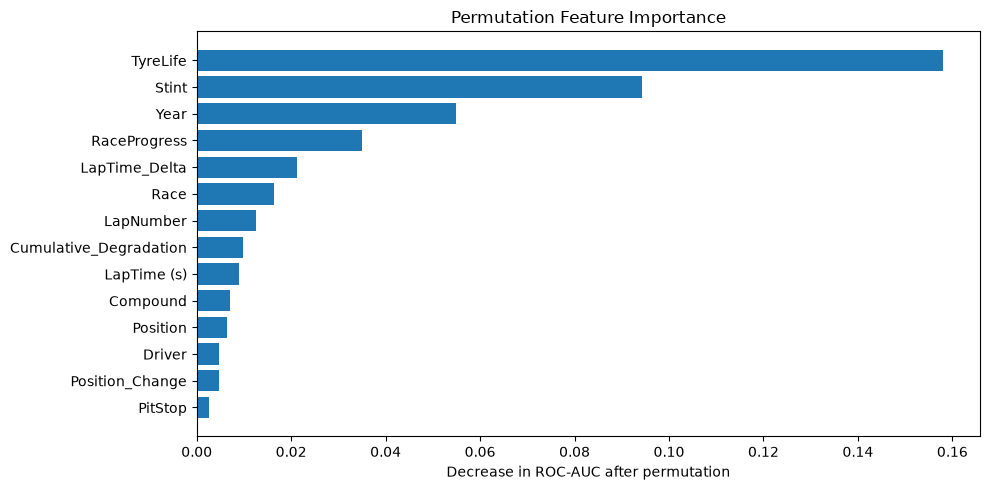

INTERPRETATION: Positive importance means shuffling the feature hurts validation ranking. Near-zero means little additional information in this model. Correlated variables can share importance.


In [24]:
# 24. Model-agnostic permutation importance
perm=permutation_importance(best_final_model,X_valid,y_valid,scoring='roc_auc',n_repeats=5,random_state=RANDOM_STATE,n_jobs=1)
importance_df=pd.DataFrame({'Feature':X_valid.columns,'Importance Mean':perm.importances_mean,'Importance Std':perm.importances_std}).sort_values('Importance Mean',ascending=False)
display(importance_df.head(30))
top=importance_df.head(min(25,len(importance_df))).sort_values('Importance Mean')
plt.figure(figsize=(10,max(5,len(top)*.25))); plt.barh(top.Feature,top['Importance Mean']); plt.xlabel('Decrease in ROC-AUC after permutation'); plt.title('Permutation Feature Importance'); plt.tight_layout(); plt.show()
print('INTERPRETATION: Positive importance means shuffling the feature hurts validation ranking. Near-zero means little additional information in this model. Correlated variables can share importance.')

## Why permutation importance?

It asks a simple human-readable question: **If I destroy this feature while keeping everything else unchanged, how much does AUC fall?** It is model-agnostic and avoids relying only on tree-specific split importance.

In [25]:
# 25. Score-bucket sanity check
score_df=pd.DataFrame({'y':y_valid.to_numpy(),'score':p})
score_df['score_decile']=pd.qcut(score_df.score,q=10,labels=False,duplicates='drop')+1
bucket_summary=score_df.groupby('score_decile').agg(rows=('y','size'),positives=('y','sum'),actual_positive_rate=('y','mean'),mean_score=('score','mean')).sort_index(ascending=False)
display(bucket_summary)
print('INTERPRETATION: A good ranking model should concentrate positives in the highest-score buckets.')

,rows,positives,actual_positive_rate,mean_score
score_decile,,,,
10,10809,9806,0.907207,0.911682
9,10809,7438,0.688130,0.676779
8,10809,3612,0.334166,0.336150
7,10809,1188,0.109908,0.103712
6,10808,368,0.034049,0.031280
5,10809,113,0.010454,0.012684
4,10809,56,0.005181,0.005584
3,10809,38,0.003516,0.002410
2,10809,10,0.000925,0.001052


INTERPRETATION: A good ranking model should concentrate positives in the highest-score buckets.


## Why score buckets?

ROC-AUC is a ranking metric. Decile analysis makes the ranking visible and provides an intuitive sanity check: high predicted scores should correspond to higher observed positive rates.

In [26]:
# 26. Refit selected configuration on all labeled data
final_model=best_final_model
print('Refitting on all labeled training rows...')
start=time.time(); final_model.fit(X,y); print(f'Fit time: {time.time()-start:.1f} seconds')

if df_test is not None:
    missing=[c for c in X.columns if c not in df_test.columns]
    if missing: raise ValueError('Test data is missing training columns: '+str(missing))

Refitting on all labeled training rows...
Fit time: 38.8 seconds


## Why refit on all labeled data?

Once model selection is complete, the validation set is no longer needed to choose the model. Refitting the frozen configuration on all labeled rows gives the final estimator maximum training information before generating test probabilities.

In [27]:
# 27. Generate submission in the original PitNextLap format
if df_test is not None:
    test_proba=final_model.predict_proba(df_test[X.columns])[:,1]
    prediction_df=pd.DataFrame({TARGET:test_proba})
    display(prediction_df.head())
    os.makedirs('My_output',exist_ok=True)
    if df_sample_out is not None and TARGET in df_sample_out.columns:
        if len(df_sample_out)!=len(prediction_df): raise ValueError('sample_submission and test row counts differ.')
        submission=df_sample_out.copy(); submission[TARGET]=prediction_df[TARGET].to_numpy(); output_path='My_output/classical_ml_submission.csv'; submission.to_csv(output_path,index=False); print('Saved:',output_path); display(submission.head())
    else:
        output_path='My_output/classical_ml_predictions.csv'; prediction_df.to_csv(output_path,index=False); print('Saved:',output_path)
else:
    print('test.csv not found; no submission generated.')

,PitNextLap
0,0.005055
1,0.005788
2,0.004213
3,0.173966
4,0.943489


Saved: My_output/classical_ml_submission.csv


,id,PitNextLap
0,439140,0.005055
1,439141,0.005788
2,439142,0.004213
3,439143,0.173966
4,439144,0.943489


# Final review checklist

### Data quality
- duplicates and constants reviewed
- missing values quantified
- numeric distributions inspected
- categorical cardinality and target rates inspected

### Leakage
- identifier-like fields flagged for human review
- preprocessing is fitted inside pipelines
- validation is held out from tuning
- prediction-time availability should be verified from domain knowledge

### Modeling
- 7–8 classical algorithms compared
- LightGBM/XGBoost/CatBoost tuned because they were the strongest families in the supplied AutoGluon configuration
- LightGBM Extra Trees explicitly tested because the supplied notebook used `extra_trees=True`
- ROC-AUC is primary; PR-AUC is secondary

### Performance
- Do not manufacture a >95% AUC by repeatedly optimizing against the same validation set
- If the score is below the target, improve features/validation design rather than only increasing complexity

### Relationship to the supplied experiment

The original notebook used target `PitNextLap`, metric `roc_auc`, training table `df_train_merged`, GBM/XGB/CAT families, a LightGBM extra-trees variant and no stacking. This notebook keeps those evidence-based choices while making every step explicit and human-auditable.

In [28]:
# 28. Compact final report
print('='*80); print('FINAL HUMAN-READABLE MODEL REPORT'); print('='*80)
print(f'Training rows:        {len(X):,}')
print(f'Training features:    {X.shape[1]:,}')
print(f'Target positive rate: {y.mean():.4%}')
print(f'Selected model:       {best_final_name}')
print(f'Validation ROC-AUC:   {best_final_auc:.5f}')
print('\nBaseline comparison:'); display(baseline_results_df)
if len(tuned_validation_df): print('\nTuned validation:'); display(tuned_validation_df)
print('\nTop permutation features:'); display(importance_df.head(15))

FINAL HUMAN-READABLE MODEL REPORT
Training rows:        540,445
Training features:    14
Target positive rate: 20.9405%
Selected model:       XGBoost
Validation ROC-AUC:   0.95678

Baseline comparison:


,Model,CV ROC-AUC Mean,CV ROC-AUC Std,CV PR-AUC Mean,CV Accuracy Mean,Time (sec)
0,Random Forest,0.952747,0.000273,0.840491,0.902580,351.252712
1,Extra Trees,0.949389,0.000502,0.833448,0.888106,258.667196
2,XGBoost,0.946701,0.000352,0.817870,0.894661,81.230536
3,LightGBM,0.945061,0.000372,0.812458,0.892908,34.254472
4,HistGradientBoosting,0.943677,0.000484,0.807690,0.891233,46.702869
5,CatBoost,0.941300,0.000519,0.802168,0.890030,127.767686
6,LightGBM Extra Trees,0.933363,0.000876,0.781234,0.882442,57.664207
7,Logistic Regression,0.843385,0.000296,0.569291,0.760239,40.103411



Tuned validation:


,Model,Validation ROC-AUC,Validation PR-AUC,Accuracy,Precision,Recall,F1
0,XGBoost,0.956784,0.851667,0.909778,0.794056,0.768446,0.781041
1,LightGBM,0.956760,0.850823,0.909741,0.793402,0.769285,0.781157
2,LightGBM Extra Trees,0.949587,0.830334,0.900656,0.776831,0.737430,0.756618
3,CatBoost,0.949128,0.826617,0.899046,0.769174,0.739949,0.754279



Top permutation features:


,Feature,Importance Mean,Importance Std
7,TyreLife,0.157953,0.000258
6,Stint,0.094387,0.000733
3,Year,0.054992,0.000622
12,RaceProgress,0.034961,0.000451
10,LapTime_Delta,0.021176,0.000194
2,Race,0.016369,0.000214
5,LapNumber,0.012559,0.000154
11,Cumulative_Degradation,0.009732,0.000132
9,LapTime (s),0.008984,0.000150
1,Compound,0.007046,0.000091


In [29]:

# ============================================================
# FINAL KAGGLE SUBMISSION
# ============================================================
# Important:
# - Submit probabilities, NOT hard 0/1 predictions.
# - The competition metric is ROC-AUC.
# - final_model has already been selected and refit on all
#   available labeled training data in the previous section.

import os
import numpy as np
import pandas as pd

KAGGLE_SUBMISSION_PATH = r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\sample_submission.csv"

# 1. Generate probabilities for the test set
test_features = df_test[X.columns].copy()
test_probability = final_model.predict_proba(test_features)[:, 1]

# 2. Build submission from the official sample format when available.
#    This preserves the exact ID column/order expected by Kaggle.
if df_sample_out is not None:
    submission = df_sample_out.copy()

    if len(submission) != len(test_probability):
        raise ValueError(
            f"Row-count mismatch: sample_submission has {len(submission)} rows "
            f"but test.csv has {len(test_probability)} rows."
        )

    if TARGET not in submission.columns:
        raise ValueError(
            f"The sample submission does not contain the expected target column: {TARGET}"
        )

    submission[TARGET] = test_probability

else:
    # Fallback only if sample_submission.csv is unavailable.
    submission = pd.DataFrame({TARGET: test_probability})

# 3. Basic validation before writing the file
if len(submission) != len(df_test):
    raise ValueError("Submission row count does not match test.csv.")

if not np.isfinite(submission[TARGET]).all():
    raise ValueError("Submission contains NaN or infinite probabilities.")

if ((submission[TARGET] < 0) | (submission[TARGET] > 1)).any():
    raise ValueError("Submission contains probabilities outside [0, 1].")

# 4. Save Kaggle-ready file
submission.to_csv(KAGGLE_SUBMISSION_PATH, index=False)

print("=" * 80)
print("KAGGLE SUBMISSION CREATED")
print("=" * 80)
print(f"File: {KAGGLE_SUBMISSION_PATH}")
print(f"Rows: {len(submission):,}")
print(f"Columns: {submission.columns.tolist()}")
print()
print("First 10 rows:")
display(submission.head(10))
print()
print("Submission summary:")
display(submission[TARGET].describe())

print(
    "\nUpload this file to Kaggle as the competition submission file."
)


KAGGLE SUBMISSION CREATED
File: D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\sample_submission.csv
Rows: 188,165
Columns: ['id', 'PitNextLap']

First 10 rows:


,id,PitNextLap
0,439140,0.005055
1,439141,0.005788
2,439142,0.004213
3,439143,0.173966
4,439144,0.943489
5,439145,0.088911
6,439146,0.000623
7,439147,0.001769
8,439148,0.025127
9,439149,0.000625



Submission summary:


count    188165.000000
mean          0.197640
std           0.306562
min           0.000011
25%           0.002223
50%           0.016274
75%           0.306520
max           0.998299
Name: PitNextLap, dtype: float64


Upload this file to Kaggle as the competition submission file.
